In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from pathlib import Path

In [2]:
raw_data = pd.read_csv('final_hcris.csv')
data_2008 = pd.read_csv('data/output/data-2008.csv')
data_2009 = pd.read_csv('data/output/data-2009.csv')
data_2010 = pd.read_csv('data/output/data-2010.csv')
data_2011 = pd.read_csv('data/output/data-2011.csv')
data_2012 = pd.read_csv('data/output/data-2012.csv')
data_2013 = pd.read_csv('data/output/data-2013.csv')
data_2014 = pd.read_csv('data/output/data-2014.csv')
data_2015 = pd.read_csv('data/output/data-2015.csv')
data_2016 = pd.read_csv('data/output/data-2016.csv')
data_2017 = pd.read_csv('data/output/data-2017.csv')
data_2018 = pd.read_csv('data/output/data-2018.csv')
data_2019 = pd.read_csv('data/output/data-2019.csv')
data = pd.concat([data_2009, data_2010, data_2011, data_2012, data_2013, data_2014, data_2015, data_2016, data_2017, data_2018, data_2019], ignore_index=True)

## Question 1

In [3]:
question_1 = (
    raw_data
    .groupby(["fyear", "provider_number"])
    .size()
    .reset_index(name="num_reports")
)
multiple_reports = question_1[question_1["num_reports"] > 1]
multiple_reports.head()

,fyear,provider_number,num_reports
106,2008,30061,2
118,2008,30093,2
182,2008,40151,2
259,2008,50158,2
271,2008,50230,2


In [4]:
hospitals_per_year = (
    multiple_reports
    .groupby("fyear")
    .size()
    .reset_index(name="num_hospitals")
)
hospitals_per_year

,fyear,num_hospitals
0,2008,42
1,2011,45
2,2012,90
3,2013,91
4,2014,102
5,2015,96
6,2016,95
7,2017,91
8,2018,101


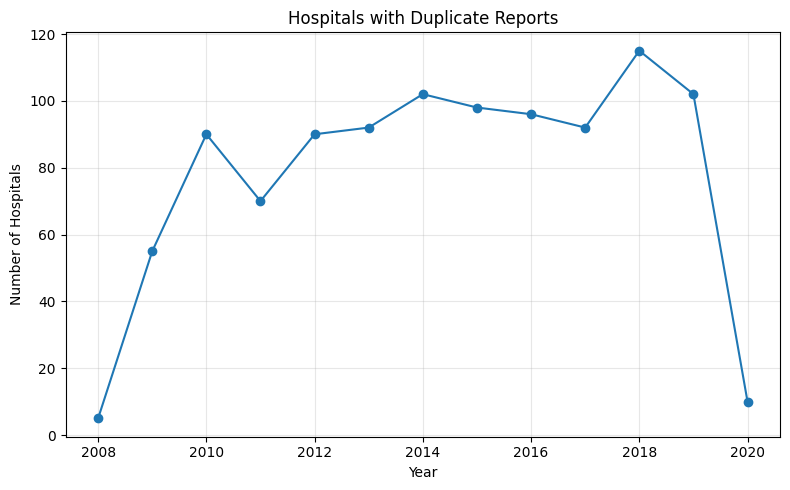

In [5]:
prof_graph = pd.DataFrame({
    "year": [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020],
    "num_hospitals": [5, 55, 90, 70, 90, 92, 102, 98, 96, 92, 115, 102, 10]
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    prof_graph["year"],
    prof_graph["num_hospitals"],
    marker="o"
)

ax.set(
    xlabel="Year",
    ylabel="Number of Hospitals",
    title="Hospitals with Duplicate Reports"
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 2

In [6]:
data['provider_number'].nunique()

6732

There are 6793 unique hospital IDs. 

## Question 3

In [7]:
df_plot = raw_data[(raw_data["fyear"] >= 2009) & (raw_data["fyear"] <= 2019)].copy()

df_plot["tot_charges"] = pd.to_numeric(df_plot["tot_charges"], errors="coerce")

df_plot = df_plot.dropna(subset=["tot_charges", "fyear"])
df_plot = df_plot[df_plot["tot_charges"] > 0]

lower = df_plot["tot_charges"].quantile(0.01)
upper = df_plot["tot_charges"].quantile(0.99)
df_plot = df_plot[
    (df_plot["tot_charges"] >= lower) &
    (df_plot["tot_charges"] <= upper)
].copy()

df_plot["log_tot_charges"] = np.log(df_plot["tot_charges"])

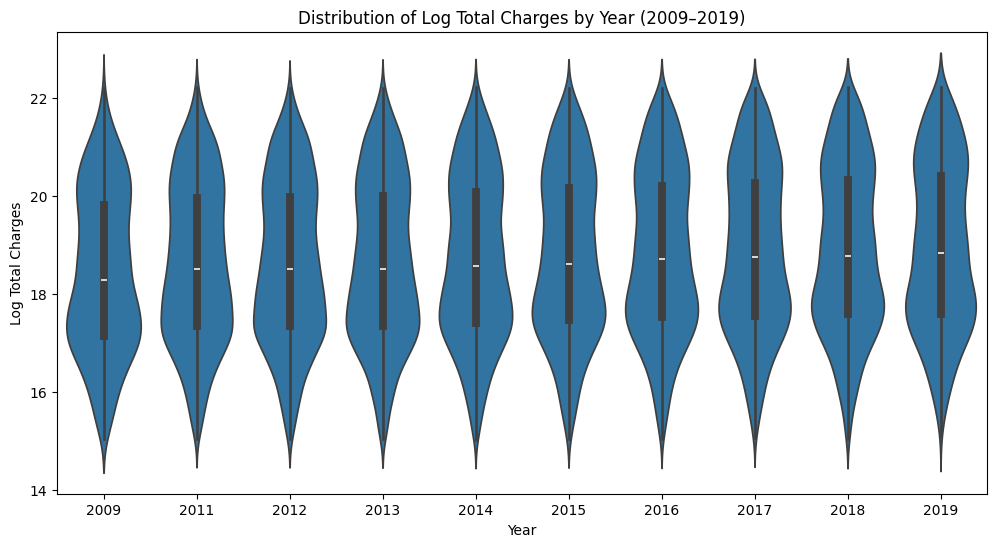

In [8]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_plot,
    x="fyear",
    y="log_tot_charges"
)

plt.title("Distribution of Log Total Charges by Year (2009–2019)")
plt.xlabel("Year")
plt.ylabel("Log Total Charges")
plt.show()

## Question 4

In [9]:
raw_data["discount_factor"] = 1 - (raw_data["tot_discounts"] / raw_data["tot_charges"])

raw_data["price_num"] = (
    raw_data["ip_charges"] +
    raw_data["icu_charges"] +
    raw_data["ancillary_charges"]
) * raw_data["discount_factor"] - raw_data["tot_mcare_payment"]

raw_data["price_denom"] = raw_data["tot_discharges"] - raw_data["mcare_discharges"]

raw_data["price"] = raw_data["price_num"] / raw_data["price_denom"]

In [10]:
df_plot = raw_data.copy()

df_plot = df_plot[(df_plot["fyear"] >= 2009) & (df_plot["fyear"] <= 2019)]

df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=["price"])

df_plot = df_plot[df_plot["price"] > 0]

In [11]:
lower = df_plot["price"].quantile(0.01)
upper = df_plot["price"].quantile(0.99)

df_plot = df_plot[
    (df_plot["price"] >= lower) &
    (df_plot["price"] <= upper)
].copy()

In [12]:
df_plot["log_price"] = np.log(df_plot["price"])

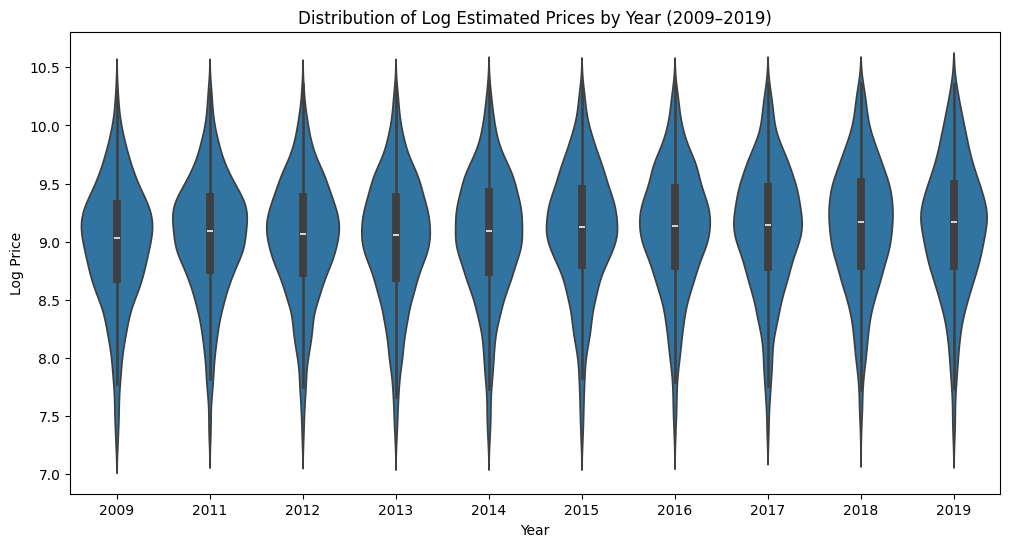

In [13]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_plot,
    x="fyear",
    y="log_price"
)

plt.title("Distribution of Log Estimated Prices by Year (2009–2019)")
plt.xlabel("Year")
plt.ylabel("Log Price")

plt.show()

## Question 5

In [14]:
df_pen = raw_data.copy()

df_pen = df_pen[(df_pen["fyear"] >= 2012) & (df_pen["fyear"] <= 2019)]

df_pen["hrrp_payment"] = pd.to_numeric(df_pen["hrrp_payment"], errors="coerce")
df_pen["hvbp_payment"] = pd.to_numeric(df_pen["hvbp_payment"], errors="coerce")

df_pen["hrrp_payment"] = df_pen["hrrp_payment"].fillna(0)
df_pen["hvbp_payment"] = df_pen["hvbp_payment"].fillna(0)

df_pen["net_payment"] = df_pen["hrrp_payment"] + df_pen["hvbp_payment"]

df_pen["penalized"] = (df_pen["net_payment"] > 0).astype(int)

share_pen = (
    df_pen.groupby("fyear")["penalized"]
    .mean()
    .reset_index()
)

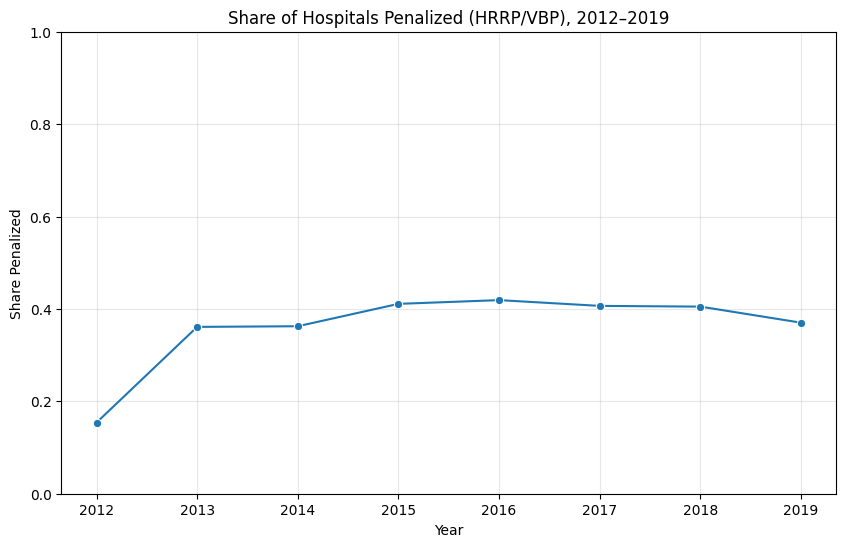

In [15]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=share_pen,
    x="fyear",
    y="penalized",
    marker="o"
)

plt.title("Share of Hospitals Penalized (HRRP/VBP), 2012–2019")
plt.xlabel("Year")
plt.ylabel("Share Penalized")
plt.ylim(0, 1)

plt.grid(True, alpha=0.3)

plt.show()

## Question 6

In [20]:
df = data.copy()

df["hrrp_payment"] = pd.to_numeric(df["hrrp_payment"], errors="coerce").abs().fillna(0)
df["hvbp_payment"] = pd.to_numeric(df["hvbp_payment"], errors="coerce").fillna(0)
df["net_penalty"]  = df["hvbp_payment"] - df["hrrp_payment"]

num_vars = [
    "tot_discounts", "tot_charges", "ip_charges", "icu_charges",
    "ancillary_charges", "tot_mcare_payment", "tot_discharges",
    "mcare_discharges", "mcaid_discharges", "beds"
]
for v in num_vars:
    df[v] = pd.to_numeric(df[v], errors="coerce")

df["discount_factor"] = 1 - df["tot_discounts"] / df["tot_charges"]
df["price_num"] = (
    (df["ip_charges"] + df["icu_charges"] + df["ancillary_charges"])
    * df["discount_factor"]
    - df["tot_mcare_payment"]
)
df["price_denom"] = df["tot_discharges"] - df["mcare_discharges"]
df["price"] = df["price_num"] / df["price_denom"]
df = df.replace([np.inf, -np.inf], np.nan)
df.loc[df["price"] <= 0, "price"] = np.nan

price_2011 = (
    df.loc[df["year"] == 2011, ["provider_number", "price"]]
    .rename(columns={"price": "price_2011"})
)
price_2014 = (
    df.loc[df["year"] == 2014, ["provider_number", "price"]]
    .rename(columns={"price": "price_2014"})
)
pen_2012 = (
    df.loc[df["year"] == 2012, ["provider_number", "net_penalty"]]
    .rename(columns={"net_penalty": "net_penalty_2012"})
)

pre_period = df.loc[df["year"].between(2009, 2011)].copy()
pre_means = (
    pre_period.groupby("provider_number", as_index=False)
    .agg(
        mean_beds_pre=("beds", "mean"),
        mean_mcaid_discharges_pre=("mcaid_discharges", "mean"),
        mean_mcare_discharges_pre=("mcare_discharges", "mean"),
    )
)

analysis = (
    price_2011
    .merge(price_2014, on="provider_number", how="inner")
    .merge(pen_2012,   on="provider_number", how="inner")
    .merge(pre_means,  on="provider_number", how="inner")
)
analysis["price_change"] = analysis["price_2014"] - analysis["price_2011"]

print("N in analysis:", len(analysis))

N in analysis: 5557


In [21]:
print("price_2011:", len(price_2011))
print("price_2014:", len(price_2014))
print("pen_2012:", len(pen_2012))
print("pre_means:", len(pre_means))

print("dup in price_2011:", price_2011["provider_number"].duplicated().sum())
print("dup in price_2014:", price_2014["provider_number"].duplicated().sum())
print("dup in pen_2012:", pen_2012["provider_number"].duplicated().sum())
print("dup in pre_means:", pre_means["provider_number"].duplicated().sum())

price_2011: 5815
price_2014: 6064
pen_2012: 6140
pre_means: 6169
dup in price_2011: 0
dup in price_2014: 0
dup in pen_2012: 0
dup in pre_means: 0


In [22]:
df_clean = (
    df.dropna(subset=["price"])
      .sort_values("provider_number")
      .drop_duplicates(subset=["provider_number", "year"], keep="first")
)

price_2011 = (
    df_clean.loc[df_clean["year"] == 2011, ["provider_number", "price"]]
    .rename(columns={"price": "price_2011"})
)
price_2014 = (
    df_clean.loc[df_clean["year"] == 2014, ["provider_number", "price"]]
    .rename(columns={"price": "price_2014"})
)
pen_2012 = (
    df_clean.loc[df_clean["year"] == 2012, ["provider_number", "net_penalty"]]
    .rename(columns={"net_penalty": "net_penalty_2012"})
)

pre_period = df_clean.loc[df_clean["year"].between(2009, 2011)].copy()
pre_means = (
    pre_period.groupby("provider_number", as_index=False)
    .agg(
        mean_beds_pre=("beds", "mean"),
        mean_mcaid_discharges_pre=("mcaid_discharges", "mean"),
        mean_mcare_discharges_pre=("mcare_discharges", "mean"),
    )
)

analysis = (
    price_2011
    .merge(price_2014, on="provider_number", how="inner")
    .merge(pen_2012,   on="provider_number", how="inner")
    .merge(pre_means,  on="provider_number", how="inner")
)
analysis["price_change"] = analysis["price_2014"] - analysis["price_2011"]

print("N in analysis:", len(analysis))
print("price_2011:", len(price_2011))

N in analysis: 2376
price_2011: 2621


In [23]:
from statsmodels.iolib.summary2 import summary_col

analysis_ols = analysis.dropna(subset=[
    "price_change",
    "net_penalty_2012",
    "mean_beds_pre",
    "mean_mcaid_discharges_pre"
]).copy()

ols1 = smf.ols("price_change ~ net_penalty_2012",
               data=analysis_ols).fit(cov_type="HC1")
ols2 = smf.ols("price_change ~ net_penalty_2012 + mean_beds_pre",
               data=analysis_ols).fit(cov_type="HC1")
ols3 = smf.ols("price_change ~ net_penalty_2012 + mean_beds_pre + mean_mcaid_discharges_pre",
               data=analysis_ols).fit(cov_type="HC1")

print(summary_col([ols1, ols2, ols3], stars=True,
                  model_names=["(1)", "(2)", "(3)"],
                  info_dict={"N": lambda x: f"{int(x.nobs)}",
                             "R2": lambda x: f"{x.rsquared:.3f}"}))


                             (1)        (2)        (3)    
----------------------------------------------------------
Intercept                 771.3117*  -190.6956  -209.0165 
                          (406.8079) (385.2290) (406.9617)
net_penalty_2012          -0.0027    0.0045     0.0060    
                          (0.0028)   (0.0079)   (0.0100)  
mean_beds_pre                        4.6235     6.5891    
                                     (3.6151)   (6.2565)  
mean_mcaid_discharges_pre                       -0.2501   
                                                (0.3511)  
R-squared                 0.0000     0.0021     0.0025    
R-squared Adj.            -0.0004    0.0012     0.0012    
N                         2358       2358       2358      
R2                        0.000      0.002      0.002     
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Question 7

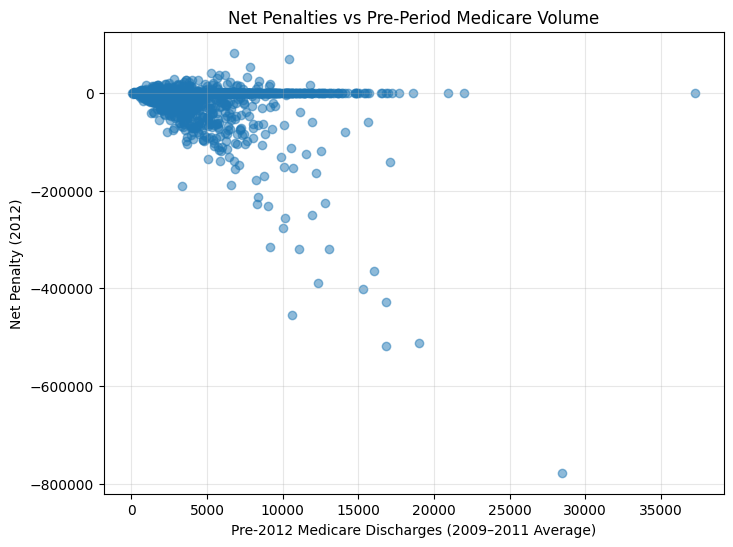

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis["mean_mcare_discharges_pre"],
    analysis["net_penalty_2012"],
    alpha=0.5
)

plt.xlabel("Pre-2012 Medicare Discharges (2009–2011 Average)")
plt.ylabel("Net Penalty (2012)")
plt.title("Net Penalties vs Pre-Period Medicare Volume")

plt.grid(True, alpha=0.3)

plt.show()

<Axes: xlabel='mean_mcare_discharges_pre', ylabel='net_penalty_2012'>

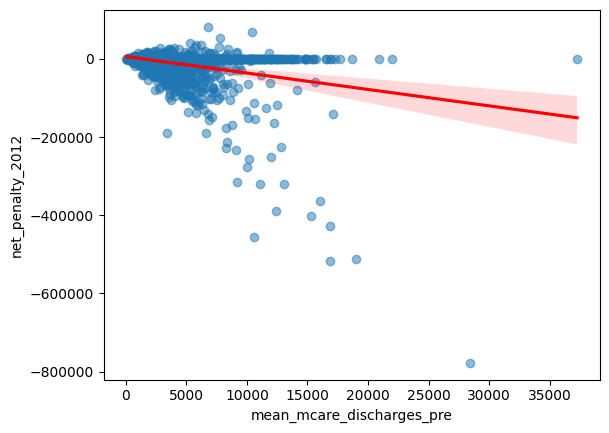

In [25]:
sns.regplot(
    data=analysis,
    x="mean_mcare_discharges_pre",
    y="net_penalty_2012",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

## Question 8

In [26]:
fs1 = smf.ols("net_penalty_2012 ~ mean_mcare_discharges_pre", data=analysis).fit(cov_type="HC1")
fs2 = smf.ols("net_penalty_2012 ~ mean_mcare_discharges_pre + mean_beds_pre", data=analysis).fit(cov_type="HC1")
fs3 = smf.ols("net_penalty_2012 ~ mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre", data=analysis).fit(cov_type="HC1")
 
rf1 = smf.ols("price_change ~ mean_mcare_discharges_pre", data=analysis).fit(cov_type="HC1")
rf2 = smf.ols("price_change ~ mean_mcare_discharges_pre + mean_beds_pre", data=analysis).fit(cov_type="HC1")
rf3 = smf.ols("price_change ~ mean_mcare_discharges_pre + mean_beds_pre + mean_mcaid_discharges_pre", data=analysis).fit(cov_type="HC1")
 
print(summary_col([fs1, fs2, fs3, rf1, rf2, rf3], stars=True,
                  model_names=["FS(1)","FS(2)","FS(3)","RF(1)","RF(2)","RF(3)"],
                  info_dict={"N": lambda x: f"{int(x.nobs)}",
                             "R2": lambda x: f"{x.rsquared:.3f}"}))


                             FS(1)       FS(2)       FS(3)       RF(1)      RF(2)      RF(3)   
-----------------------------------------------------------------------------------------------
Intercept                 5648.7735** 6348.2367** 6265.5726** -1039.8389  -1094.2949 -250.0924 
                          (2864.3257) (3187.4267) (3111.3976) (1032.2865) (990.8787) (516.1313)
mean_mcare_discharges_pre -4.1952***  -2.9940***  -2.3623***  0.3993      0.3058     0.1736    
                          (0.9378)    (0.8487)    (0.8470)    (0.2944)    (0.4640)   (0.4107)  
mean_beds_pre                         -22.8178    -54.4047**              1.7765     3.2626*   
                                      (17.2659)   (24.1793)               (3.8308)   (1.7282)  
mean_mcaid_discharges_pre                         2.9764***                          -0.1951   
                                                  (0.9388)                           (0.2407)  
R-squared                 0.1130      0

## Question 9*

In [28]:
from linearmodels.iv import IV2SLS

analysis_iv = analysis.dropna(subset=[
    "price_change", "net_penalty_2012",
    "mean_mcare_discharges_pre", "mean_beds_pre", "mean_mcaid_discharges_pre"
]).copy()

iv1 = IV2SLS.from_formula(
    "price_change ~ 1 + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv).fit(cov_type="robust")

iv2 = IV2SLS.from_formula(
    "price_change ~ 1 + mean_beds_pre + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv).fit(cov_type="robust")

iv3 = IV2SLS.from_formula(
    "price_change ~ 1 + mean_beds_pre + mean_mcaid_discharges_pre + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv).fit(cov_type="robust")

print(iv1.summary)
print(iv2.summary)
print(iv3.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:           price_change   R-squared:                     -0.0183
Estimator:                    IV-2SLS   Adj. R-squared:                -0.0188
No. Observations:                2358   F-statistic:                    1.0208
Date:                Fri, Apr 03 2026   P-value (F-stat)                0.3123
Time:                        01:46:28   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
Intercept            155.27     295.53     0.5254     0.5993     -423.96      734.49
net_penalty_2012    -0.0662 

In [29]:
from linearmodels.iv import IV2SLS
 
analysis_iv = analysis.dropna(subset=[
    "price_change", "net_penalty_2012",
    "mean_mcare_discharges_pre", "mean_beds_pre", "mean_mcaid_discharges_pre"
]).copy()
 
iv1 = IV2SLS.from_formula(
    "price_change ~ 1 + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv).fit(cov_type="robust")
 
iv2 = IV2SLS.from_formula(
    "price_change ~ 1 + mean_beds_pre + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv).fit(cov_type="robust")
 
iv3 = IV2SLS.from_formula(
    "price_change ~ 1 + mean_beds_pre + mean_mcaid_discharges_pre + [net_penalty_2012 ~ mean_mcare_discharges_pre]",
    data=analysis_iv).fit(cov_type="robust")
 
# Print clean table
iv_table = pd.DataFrame({
    "(1)": [iv1.params.get("Intercept", np.nan),
            iv1.std_errors.get("Intercept", np.nan),
            iv1.params.get("net_penalty_2012", np.nan),
            iv1.std_errors.get("net_penalty_2012", np.nan),
            np.nan, np.nan, np.nan, np.nan,
            int(iv1.nobs), iv1.rsquared],
    "(2)": [iv2.params.get("Intercept", np.nan),
            iv2.std_errors.get("Intercept", np.nan),
            iv2.params.get("net_penalty_2012", np.nan),
            iv2.std_errors.get("net_penalty_2012", np.nan),
            iv2.params.get("mean_beds_pre", np.nan),
            iv2.std_errors.get("mean_beds_pre", np.nan),
            np.nan, np.nan,
            int(iv2.nobs), iv2.rsquared],
    "(3)": [iv3.params.get("Intercept", np.nan),
            iv3.std_errors.get("Intercept", np.nan),
            iv3.params.get("net_penalty_2012", np.nan),
            iv3.std_errors.get("net_penalty_2012", np.nan),
            iv3.params.get("mean_beds_pre", np.nan),
            iv3.std_errors.get("mean_beds_pre", np.nan),
            iv3.params.get("mean_mcaid_discharges_pre", np.nan),
            iv3.std_errors.get("mean_mcaid_discharges_pre", np.nan),
            int(iv3.nobs), iv3.rsquared],
}, index=["Intercept", "Intercept SE",
          "Net Penalty (IV)", "Net Penalty SE",
          "Avg Beds (Pre-2012)", "Beds SE",
          "Avg Medicaid Discharges (Pre-2012)", "Medicaid SE",
          "Num.Obs.", "R2"])
 
print(iv_table.round(3))

                                         (1)       (2)       (3)
Intercept                            155.267   200.931   210.440
Intercept SE                         295.529   569.581   683.358
Net Penalty (IV)                      -0.066    -0.072    -0.074
Net Penalty SE                         0.066     0.155     0.176
Avg Beds (Pre-2012)                      NaN    -0.450    -0.736
Beds SE                                  NaN     7.454    11.155
Avg Medicaid Discharges (Pre-2012)       NaN       NaN     0.024
Medicaid SE                              NaN       NaN     0.320
Num.Obs.                            2358.000  2358.000  2358.000
R2                                    -0.018    -0.022    -0.023


## Question 10

The IV estimate identifies a local ATE, reflecting the effect of penalties on prices for hospitals whose penalty status is influenced affected by their pre-2012 Medicare discharges. This effect applies mostly to hospitals with higher Medicare exposure and can be different from overall ATE, reflecing the average effect across all hospitals.